In [2]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

In [3]:
# Load the preprocessed dataset

df = pd.read_csv("preprocessed_data.csv")

display(df.head())

print("Dataset shape:", df.shape)

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

,age,placement_status,gpa,boolean_Computer Science,boolean_Information Technology,boolean_Electrical Engineering,boolean_Mechanical Engineering,boolean_Electronics and Communication
0,25,1,3.7,1,0,0,0,0
1,24,1,3.6,0,0,1,0,0
2,26,1,3.8,0,0,0,1,0
3,23,0,3.5,0,1,0,0,0
4,24,1,3.9,1,0,0,0,0


Dataset shape: (700, 8)

Data types:
age                                        int64
placement_status                           int64
gpa                                      float64
boolean_Computer Science                   int64
boolean_Information Technology             int64
boolean_Electrical Engineering             int64
boolean_Mechanical Engineering             int64
boolean_Electronics and Communication      int64
dtype: object

Missing values:
age                                      0
placement_status                         0
gpa                                      0
boolean_Computer Science                 0
boolean_Information Technology           0
boolean_Electrical Engineering           0
boolean_Mechanical Engineering           0
boolean_Electronics and Communication    0
dtype: int64


,Count,Percentage
placement_status,,
0,130,18.571429
1,570,81.428571


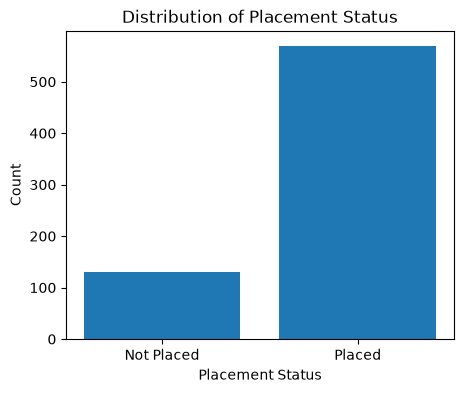

In [4]:
#Target Distribution

target_count = df['placement_status'].value_counts().sort_index()
target_percent = df['placement_status'].value_counts(
    normalize=True
).sort_index()*100

target_summary = pd.DataFrame({
    'Count': target_count,
    'Percentage': target_percent
})

display(target_summary)

#Bar Plot of Target Variable

plt.figure(figsize=(5,4))
plt.bar(
    target_count.index,
    target_count.values
)

plt.xlabel('Placement Status')
plt.ylabel('Count')
plt.title('Distribution of Placement Status')
plt.xticks([0,1], ['Not Placed', 'Placed'])
plt.show()

In [5]:
#Split Data into Training and Testing Sets

y = df['placement_status']
X = df.drop(columns=['placement_status'])

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print(f'The number of training observations = {X_train.shape[0]}')
print(f'The number of testing observations = {X_test.shape[0]}')

The number of training observations = 525
The number of testing observations = 175


In [6]:
#Standardize Predictor Variables

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [7]:
#Gaussian Naive Bayes

bayes = GaussianNB()

bayes.fit(X_train_scaled, y_train)

y_pred = bayes.predict(X_test_scaled)
y_prob = bayes.predict_proba(X_test_scaled)[:,1]

Accuracy: 0.7943
Error Rate: 0.2057
              precision    recall  f1-score   support

           0       0.33      0.09      0.14        33
           1       0.82      0.96      0.88       142

    accuracy                           0.79       175
   macro avg       0.58      0.52      0.51       175
weighted avg       0.73      0.79      0.74       175



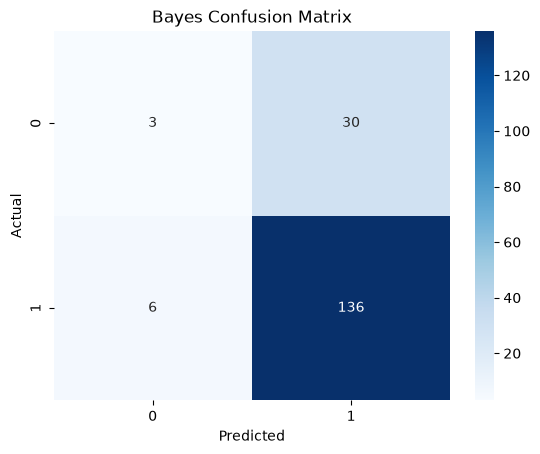

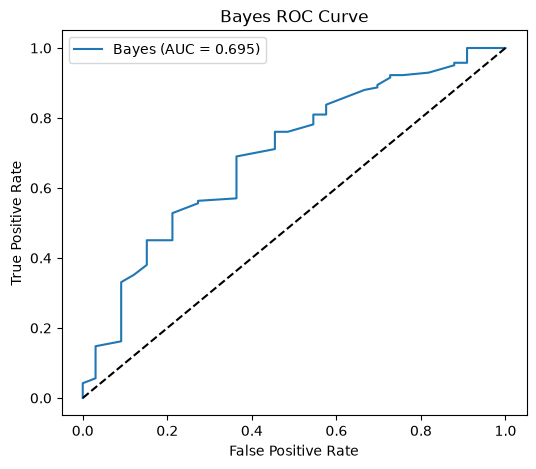

In [8]:
# Model Performance

accuracy = accuracy_score(y_test, y_pred)
error_rate = 1 - accuracy

print(f"Accuracy: {accuracy:.4f}")
print(f"Error Rate: {error_rate:.4f}")

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Bayes Confusion Matrix")

plt.show()

fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, label=f"Bayes (AUC = {auc:.3f})")
plt.plot([0,1],[0,1],"k--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Bayes ROC Curve")
plt.legend()


plt.show()

In [ ]:
# Train the LDA model and make predictions

lda = LinearDiscriminantAnalysis()

lda.fit(X_train_scaled, y_train)

lda_pred = lda.predict(X_test_scaled)
lda_prob = lda.predict_proba(X_test_scaled)[:, 1]

In [19]:
# LDA Prior Optimization

results = []

for prior_0 in np.arange(0.20, 0.61, 0.01):
    prior_1 = 1 - prior_0

    lda = LinearDiscriminantAnalysis(
        priors=[prior_0, prior_1]
    )

    lda.fit(X_train_scaled, y_train)
    lda_pred = lda.predict(X_test_scaled)

    tn, fp, fn, tp = confusion_matrix(
        y_test,
        lda_pred
    ).ravel()

    type_1_error = fp / (tn + fp)
    type_2_error = fn / (fn + tp)

    ber = (type_1_error + type_2_error) / 2

    results.append({
        "Prior 0": prior_0,
        "Prior 1": prior_1,
        "Type I Error": type_1_error,
        "Type II Error": type_2_error,
        "BER": ber
    })

lda_results = pd.DataFrame(results)

best_row = lda_results.loc[
    lda_results["BER"].idxmin()
]

print(best_row)

Prior 0          0.410000
Prior 1          0.590000
Type I Error     0.424242
Type II Error    0.169014
BER              0.296628
Name: 21, dtype: float64


LDA Priors: [0.4, 0.6]
LDA Accuracy: 0.7829
LDA Error Rate: 0.2171

Classification Report:
              precision    recall  f1-score   support

           0       0.44      0.58      0.50        33
           1       0.89      0.83      0.86       142

    accuracy                           0.78       175
   macro avg       0.67      0.70      0.68       175
weighted avg       0.81      0.78      0.79       175



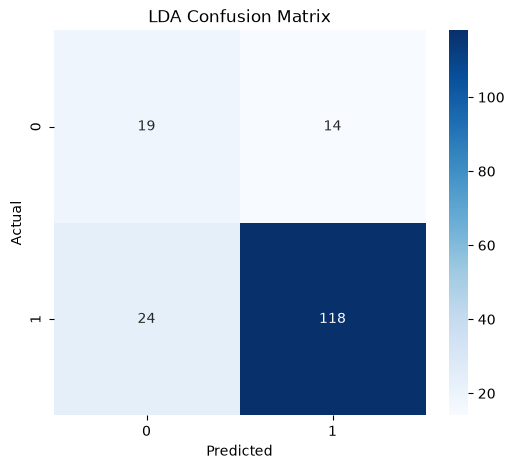

ROC-AUC Score: 0.731


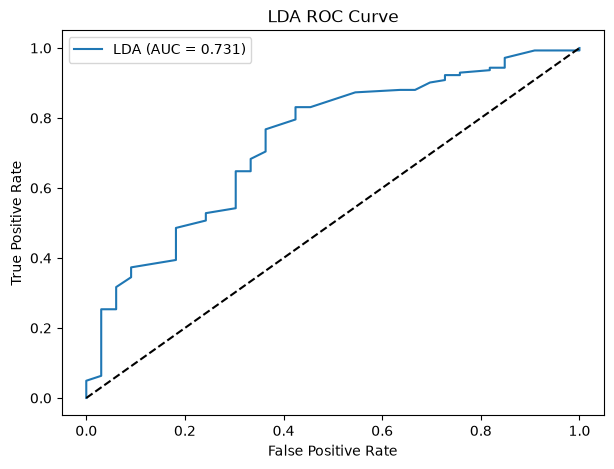

In [16]:
# Train LDA Model with adjusted priors

# Train Optimized LDA Model

lda = LinearDiscriminantAnalysis(
    priors=[0.41, 0.59]
)

lda.fit(X_train_scaled, y_train)

lda_pred = lda.predict(X_test_scaled)
lda_prob = lda.predict_proba(X_test_scaled)[:, 1]
# Evaluate LDA Model

lda_accuracy = accuracy_score(y_test, lda_pred)
lda_error_rate = 1 - lda_accuracy

print("LDA Priors: [0.4, 0.6]")
print(f"LDA Accuracy: {lda_accuracy:.4f}")
print(f"LDA Error Rate: {lda_error_rate:.4f}")

print("\nClassification Report:")
print(classification_report(
    y_test,
    lda_pred,
    zero_division=0
))

# LDA Confusion Matrix

lda_cm = confusion_matrix(y_test, lda_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    lda_cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("LDA Confusion Matrix")

plt.show()

# LDA ROC Curve

lda_fpr, lda_tpr, _ = roc_curve(y_test, lda_prob)
lda_auc = roc_auc_score(y_test, lda_prob)

print(f"ROC-AUC Score: {lda_auc:.3f}")

plt.figure(figsize=(7, 5))

plt.plot(
    lda_fpr,
    lda_tpr,
    label=f"LDA (AUC = {lda_auc:.3f})"
)

plt.plot([0, 1], [0, 1], "k--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("LDA ROC Curve")
plt.legend()

plt.show()